<a href="https://colab.research.google.com/github/BVCAE/yocto_modify/blob/main/yolov11n_trained_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Wed Apr 30 04:32:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

!cp /content/gdrive/MyDrive/data_classes_reduced.zip /content

Mounted at /content/gdrive


In [ ]:
# Unzip images to a custom data folder
!unzip -q /content/data_classes_reduced.zip -d /content/custom_data

In [ ]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

# TO DO: Improve robustness of train_val_split.py script so it can handle nested data folders, etc
!python train_val_split.py --datapath="/content/custom_data" --train_pct=0.9

--2025-04-30 04:33:30--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2025-04-30 04:33:31 (52.9 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 511
Number of annotation files: 511
Images moving to train: 459
Images moving to validation: 52


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 36
names:
- apple
- banana
- beetroot
- bell pepper
- cabbage
- capsicum
- carrot
- cauliflower
- chilli pepper
- corn
- cucumber
- eggplant
- garlic
- ginger
- grapes
- jalepeno
- kiwi
- leettuce
- lemon
- mango
- onion
- orange
- paprika
- pear
- peas
- pineapple
- pomegranate
- potato
- raddish
- soy beans
- spinach
- sweetcorn
- sweetpotato
- tomato
- turnip
- watermelon


In [ ]:
!yolo detect train data=/content/data.yaml model=yolo11n.pt epochs=36 imgsz=320 project="/content/drive/MyDrive/yolov11n_project/" name="train"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100% 5.35M/5.35M [00:00<00:00, 279MB/s]
Ultralytics 8.3.121 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/data.yaml, epochs=36, time=None, patience=100, batch=16, imgsz=320, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/drive/MyDrive/yolov11n_project/, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=

In [ ]:
!yolo detect predict model=/content/drive/MyDrive/yolov11n_project/train/weights/best.pt source=data/validation/images save=True

Ultralytics 8.3.121 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,589,172 parameters, 0 gradients, 6.4 GFLOPs

image 1/52 /content/data/validation/images/037af28d-Image_7.jpg: 320x224 1 tomato, 42.5ms
image 2/52 /content/data/validation/images/07af530a-Image_93.jpg: 256x320 4 tomatos, 41.6ms
image 3/52 /content/data/validation/images/11bae1f1-Image_59.png: 320x256 1 apple, 40.2ms
image 4/52 /content/data/validation/images/11ec715b-Image_54.jpg: 192x320 1 banana, 52.3ms
image 5/52 /content/data/validation/images/13afa9cb-Image_32.jpg: 320x320 2 lemons, 10.6ms
image 6/52 /content/data/validation/images/1cf1138e-Image_86.jpg: 192x320 1 apple, 8.4ms
image 7/52 /content/data/validation/images/1fcafb1e-Image_3.jpg: 288x320 1 banana, 40.9ms
image 8/52 /content/data/validation/images/258b606a-Image_76.png: 320x320 1 apple, 8.5ms
image 9/52 /content/data/validation/images/27075cc8-Image_9.jpg: 320x224 3 potatos, 8.2ms
image 10/52 /content/

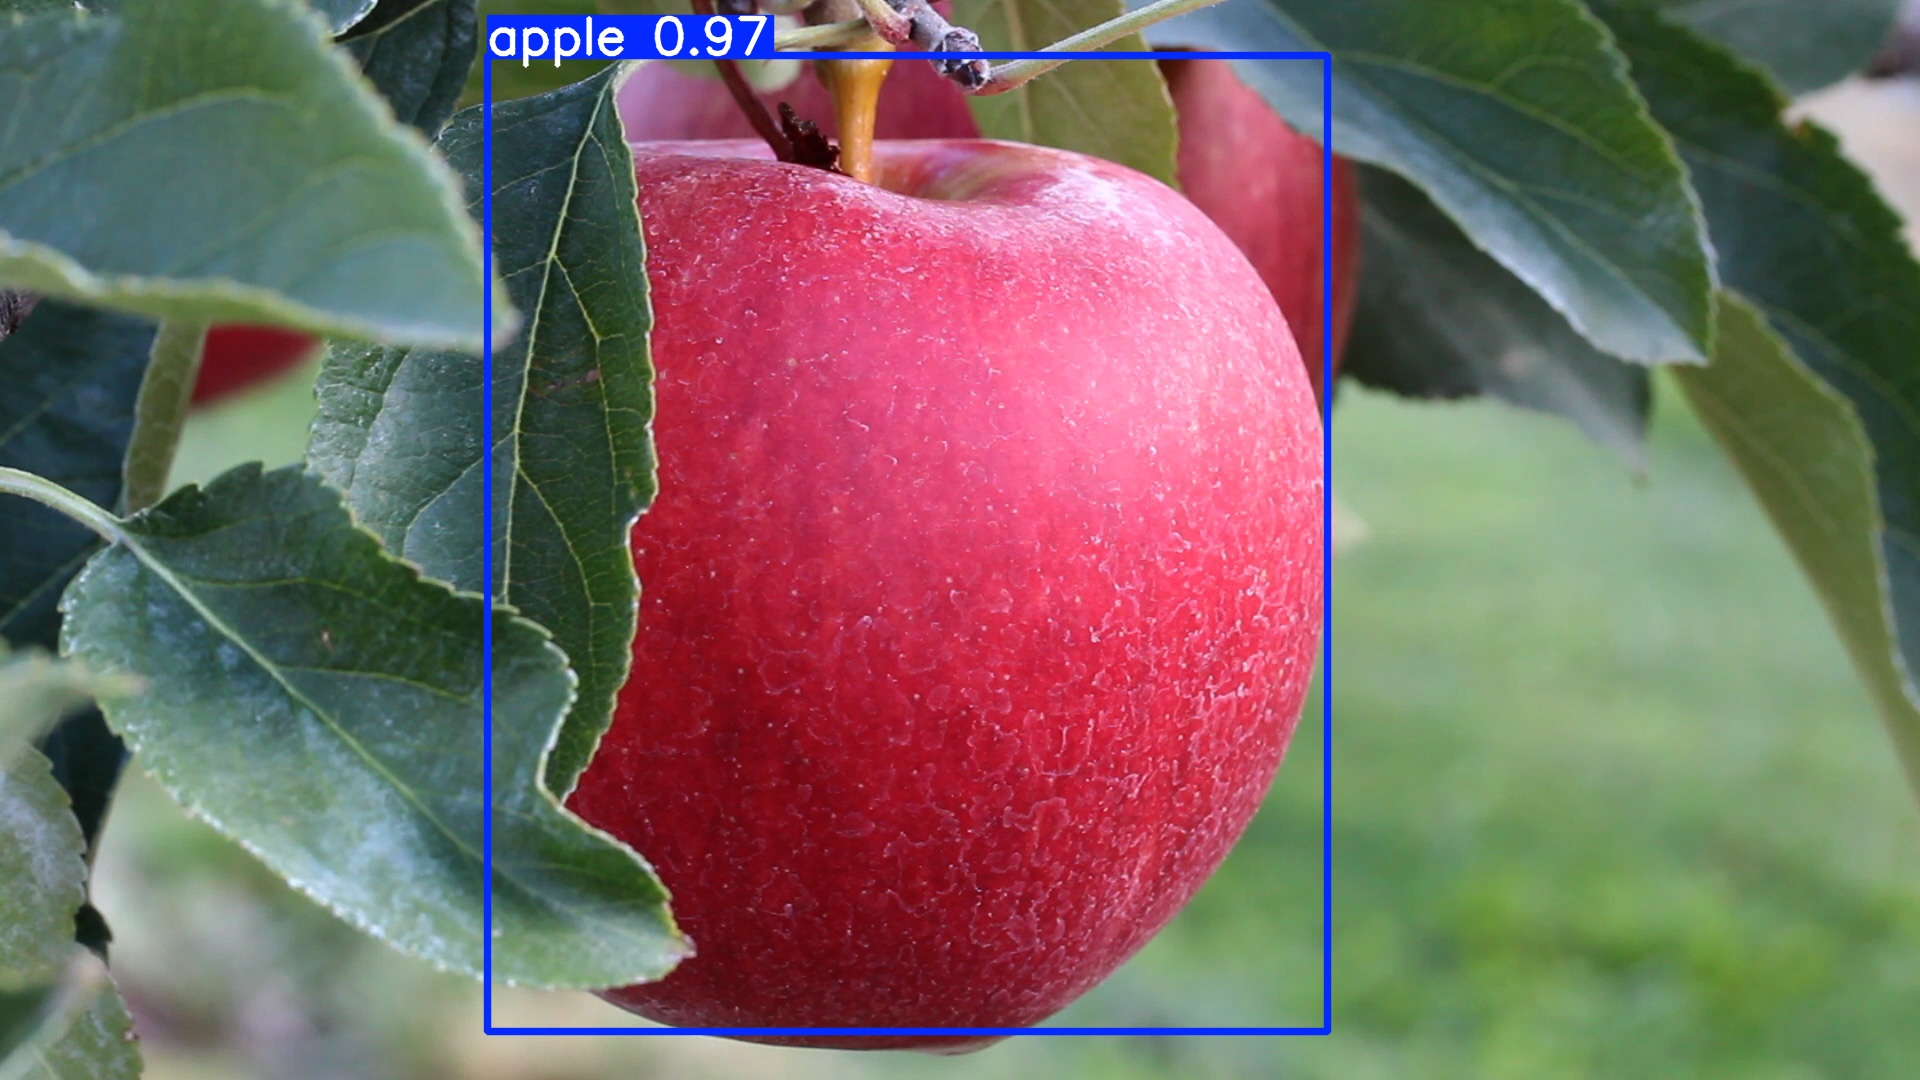

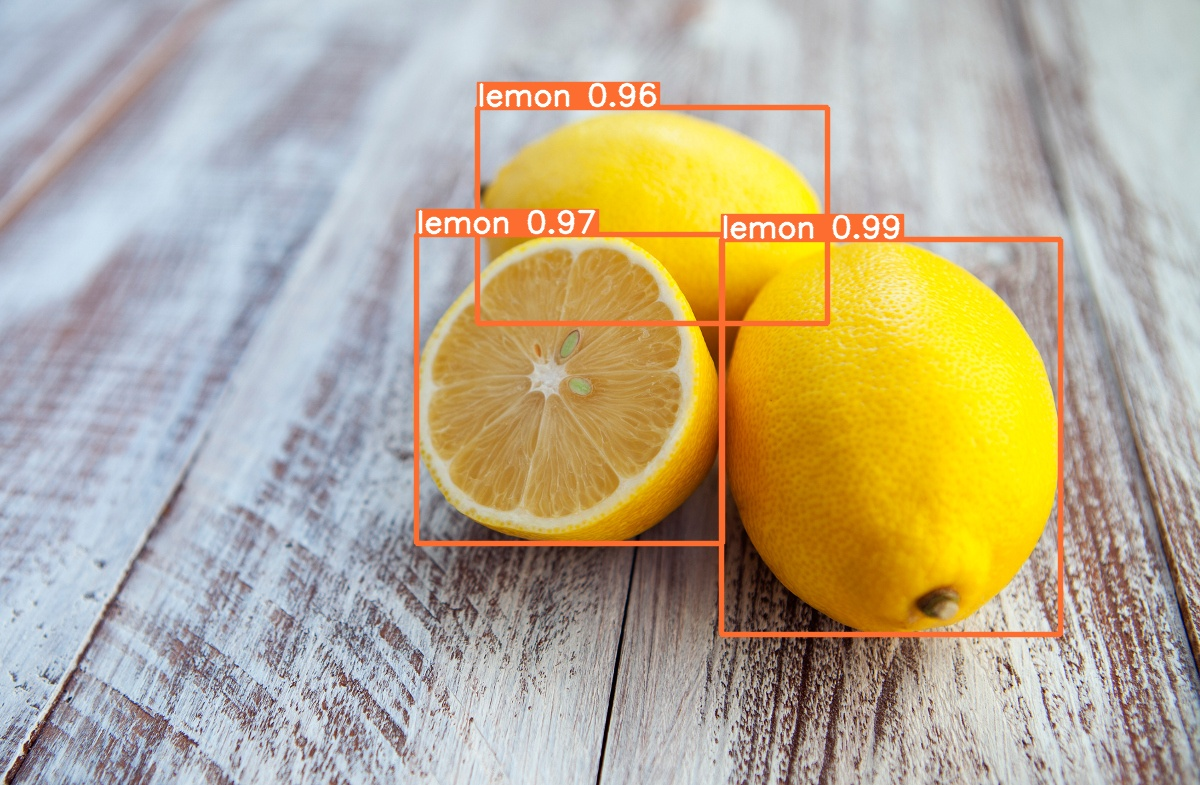

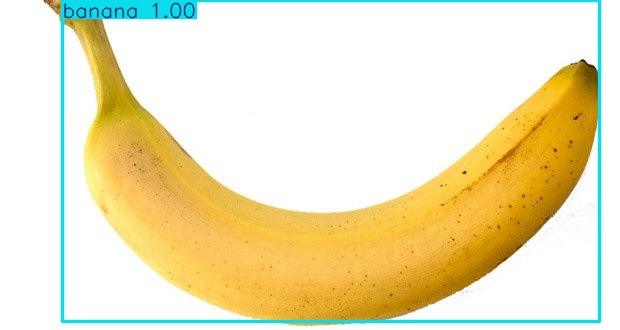

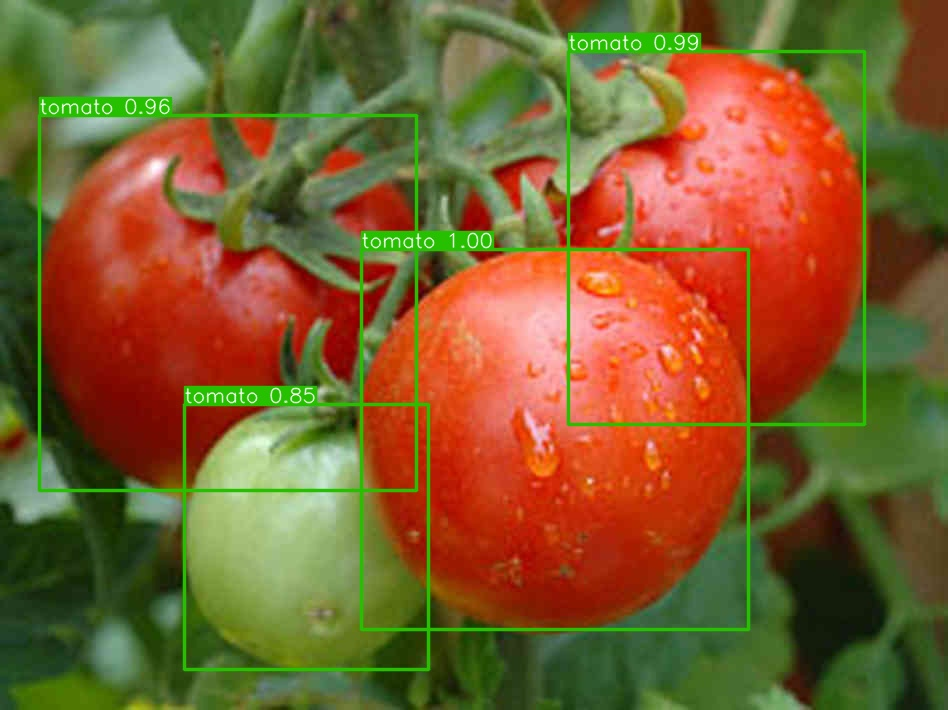

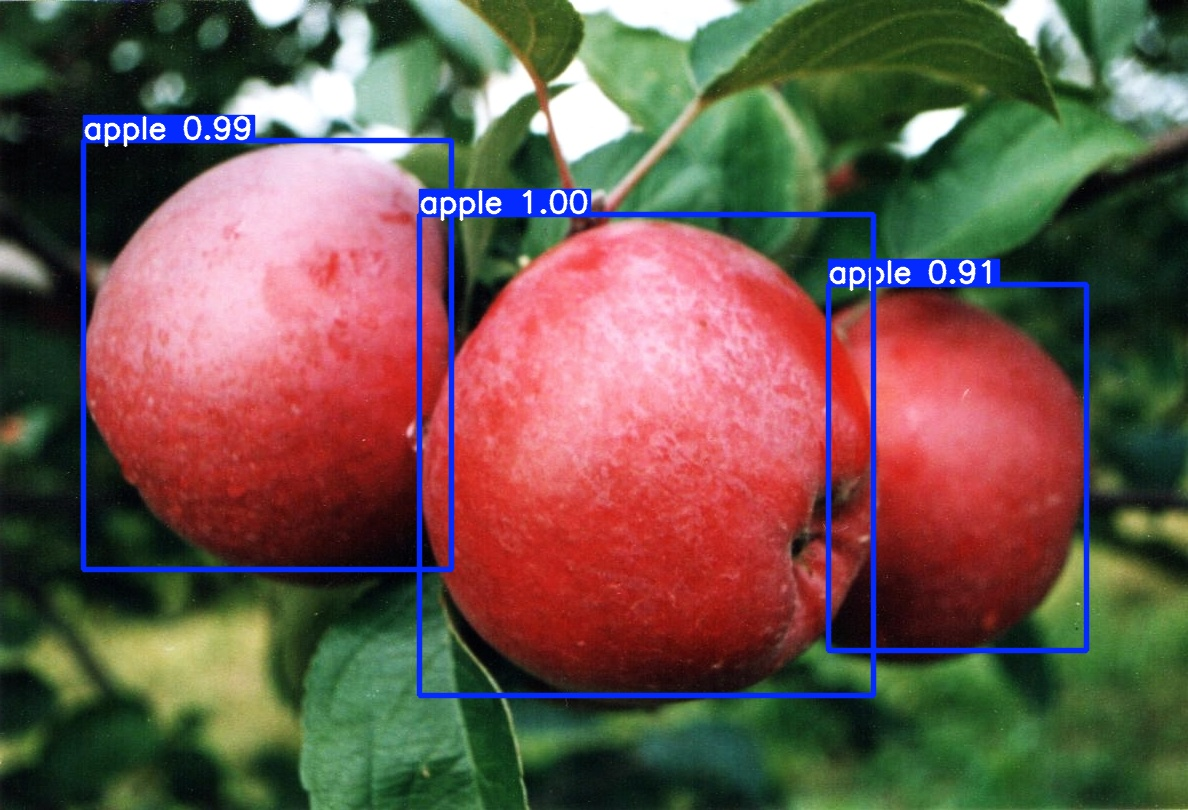

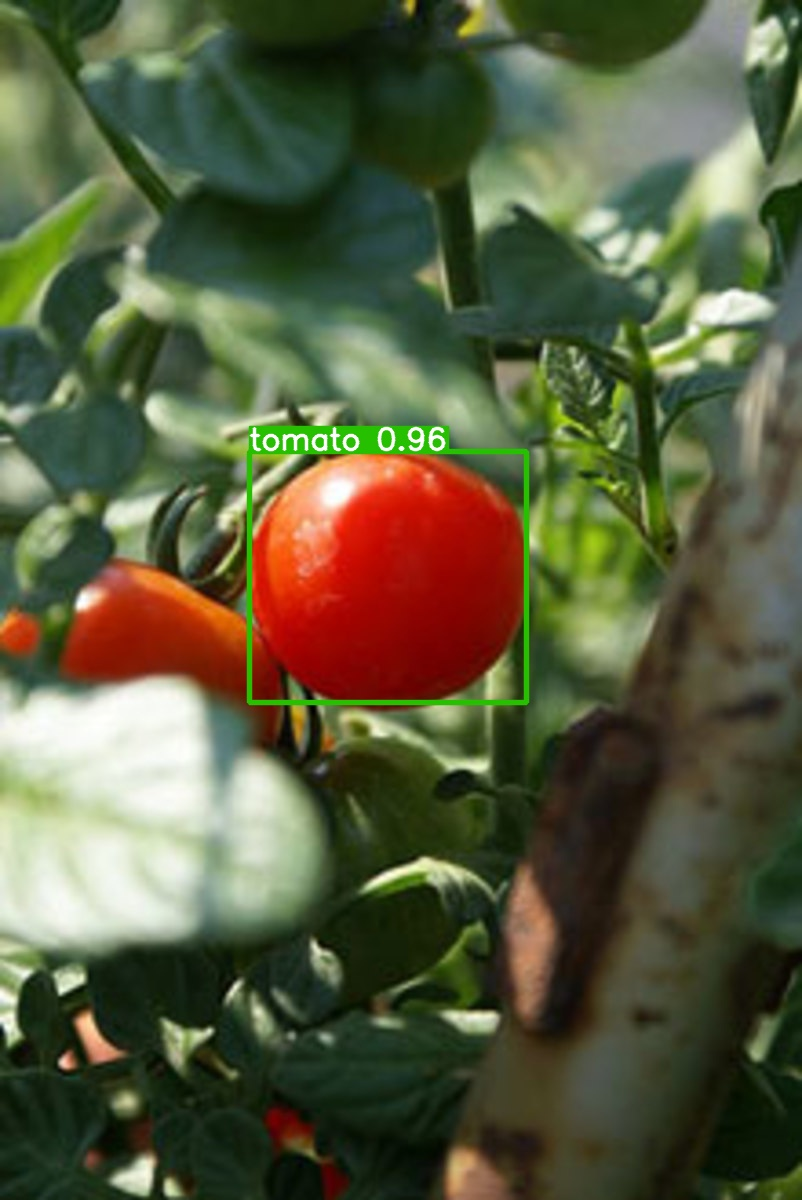

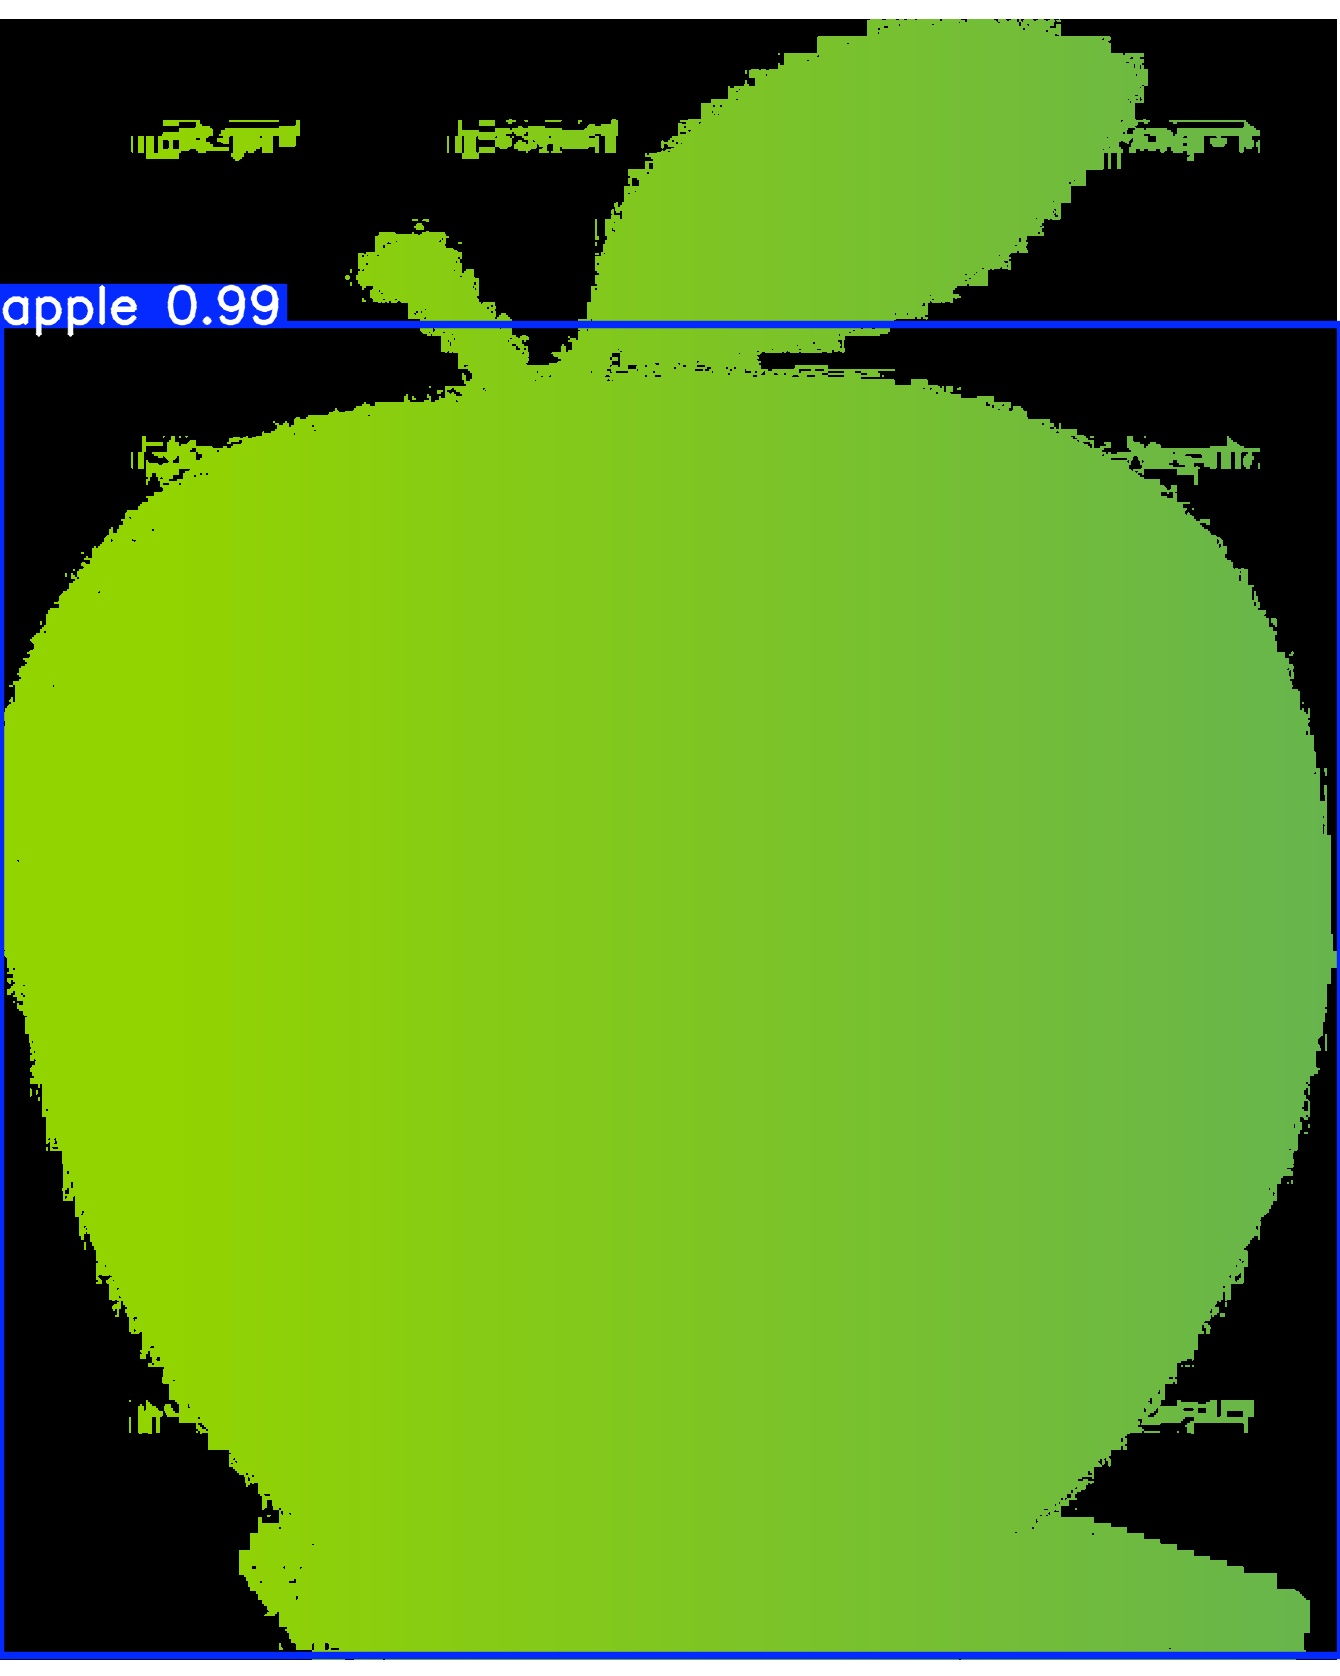

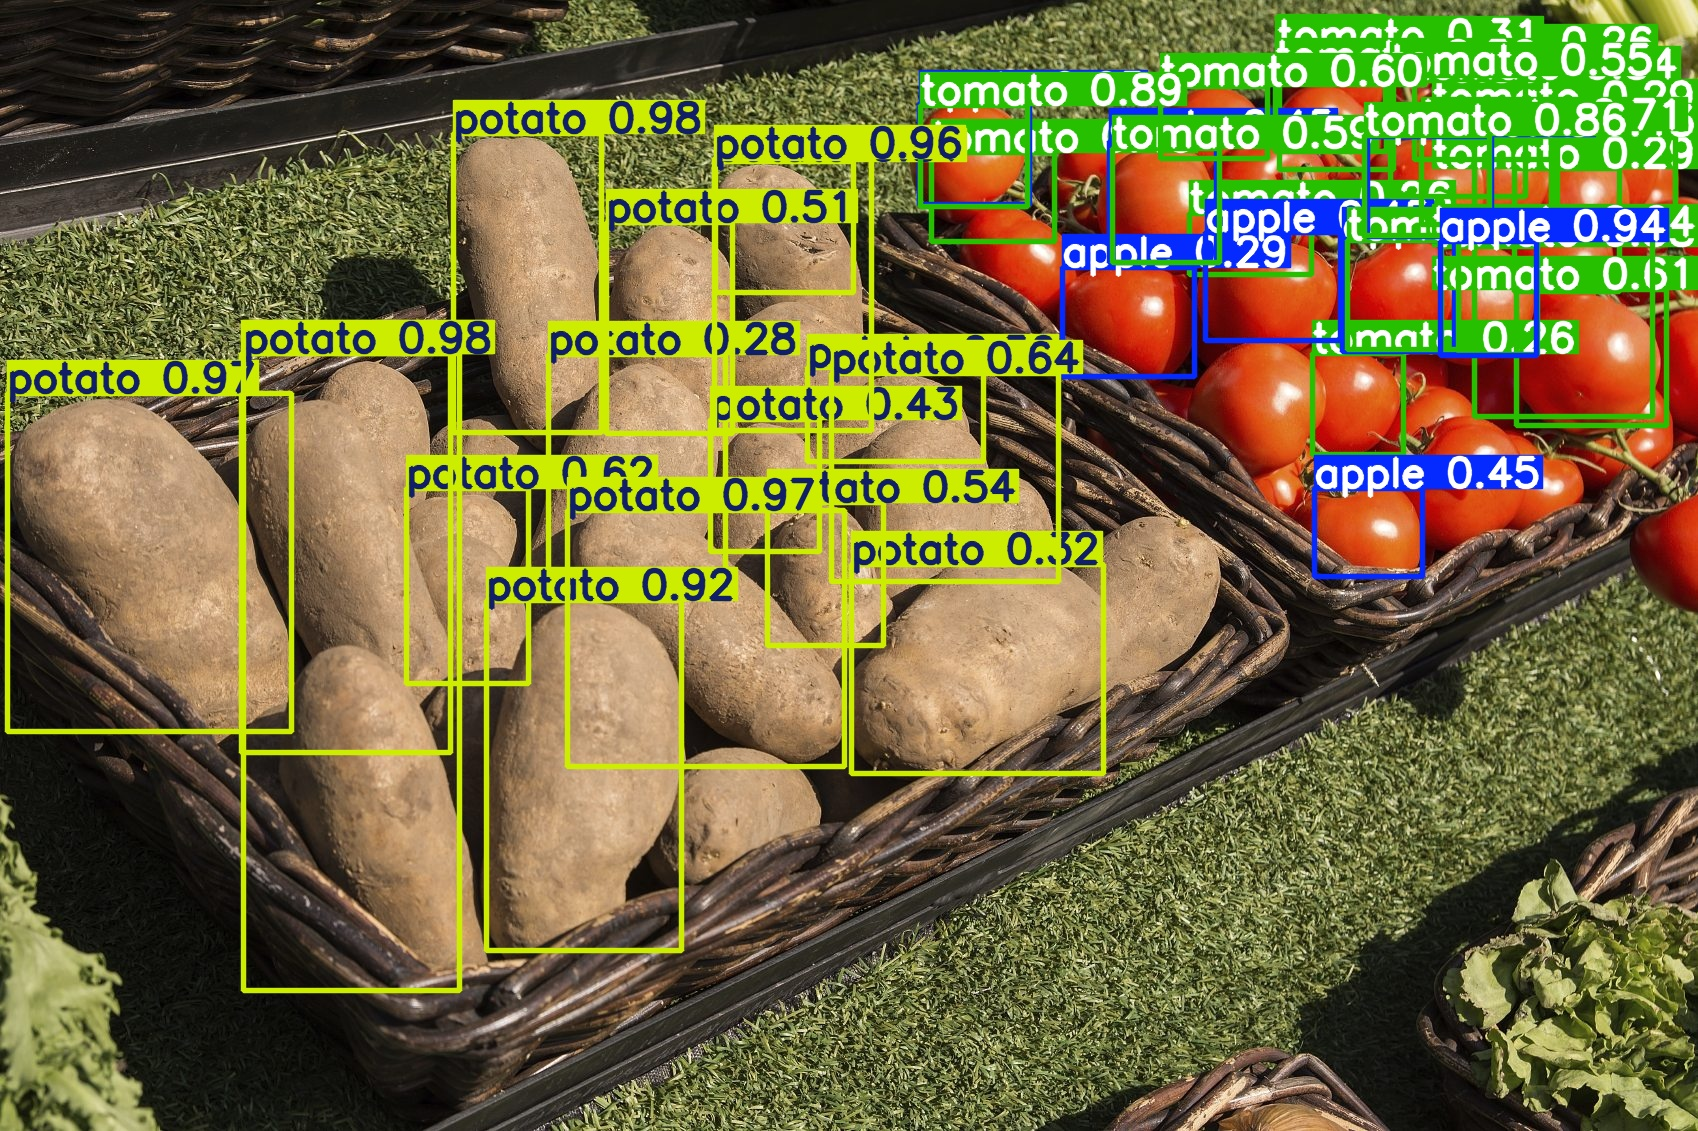

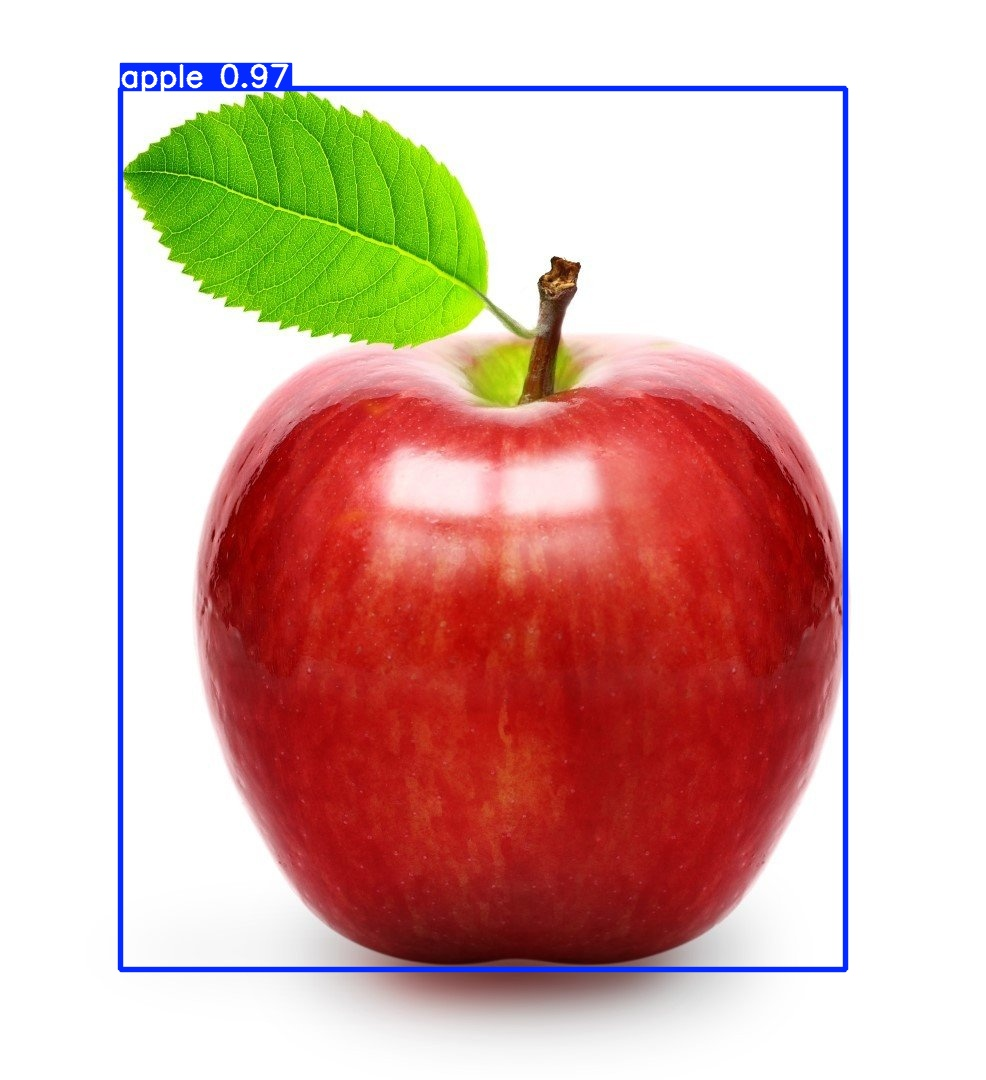

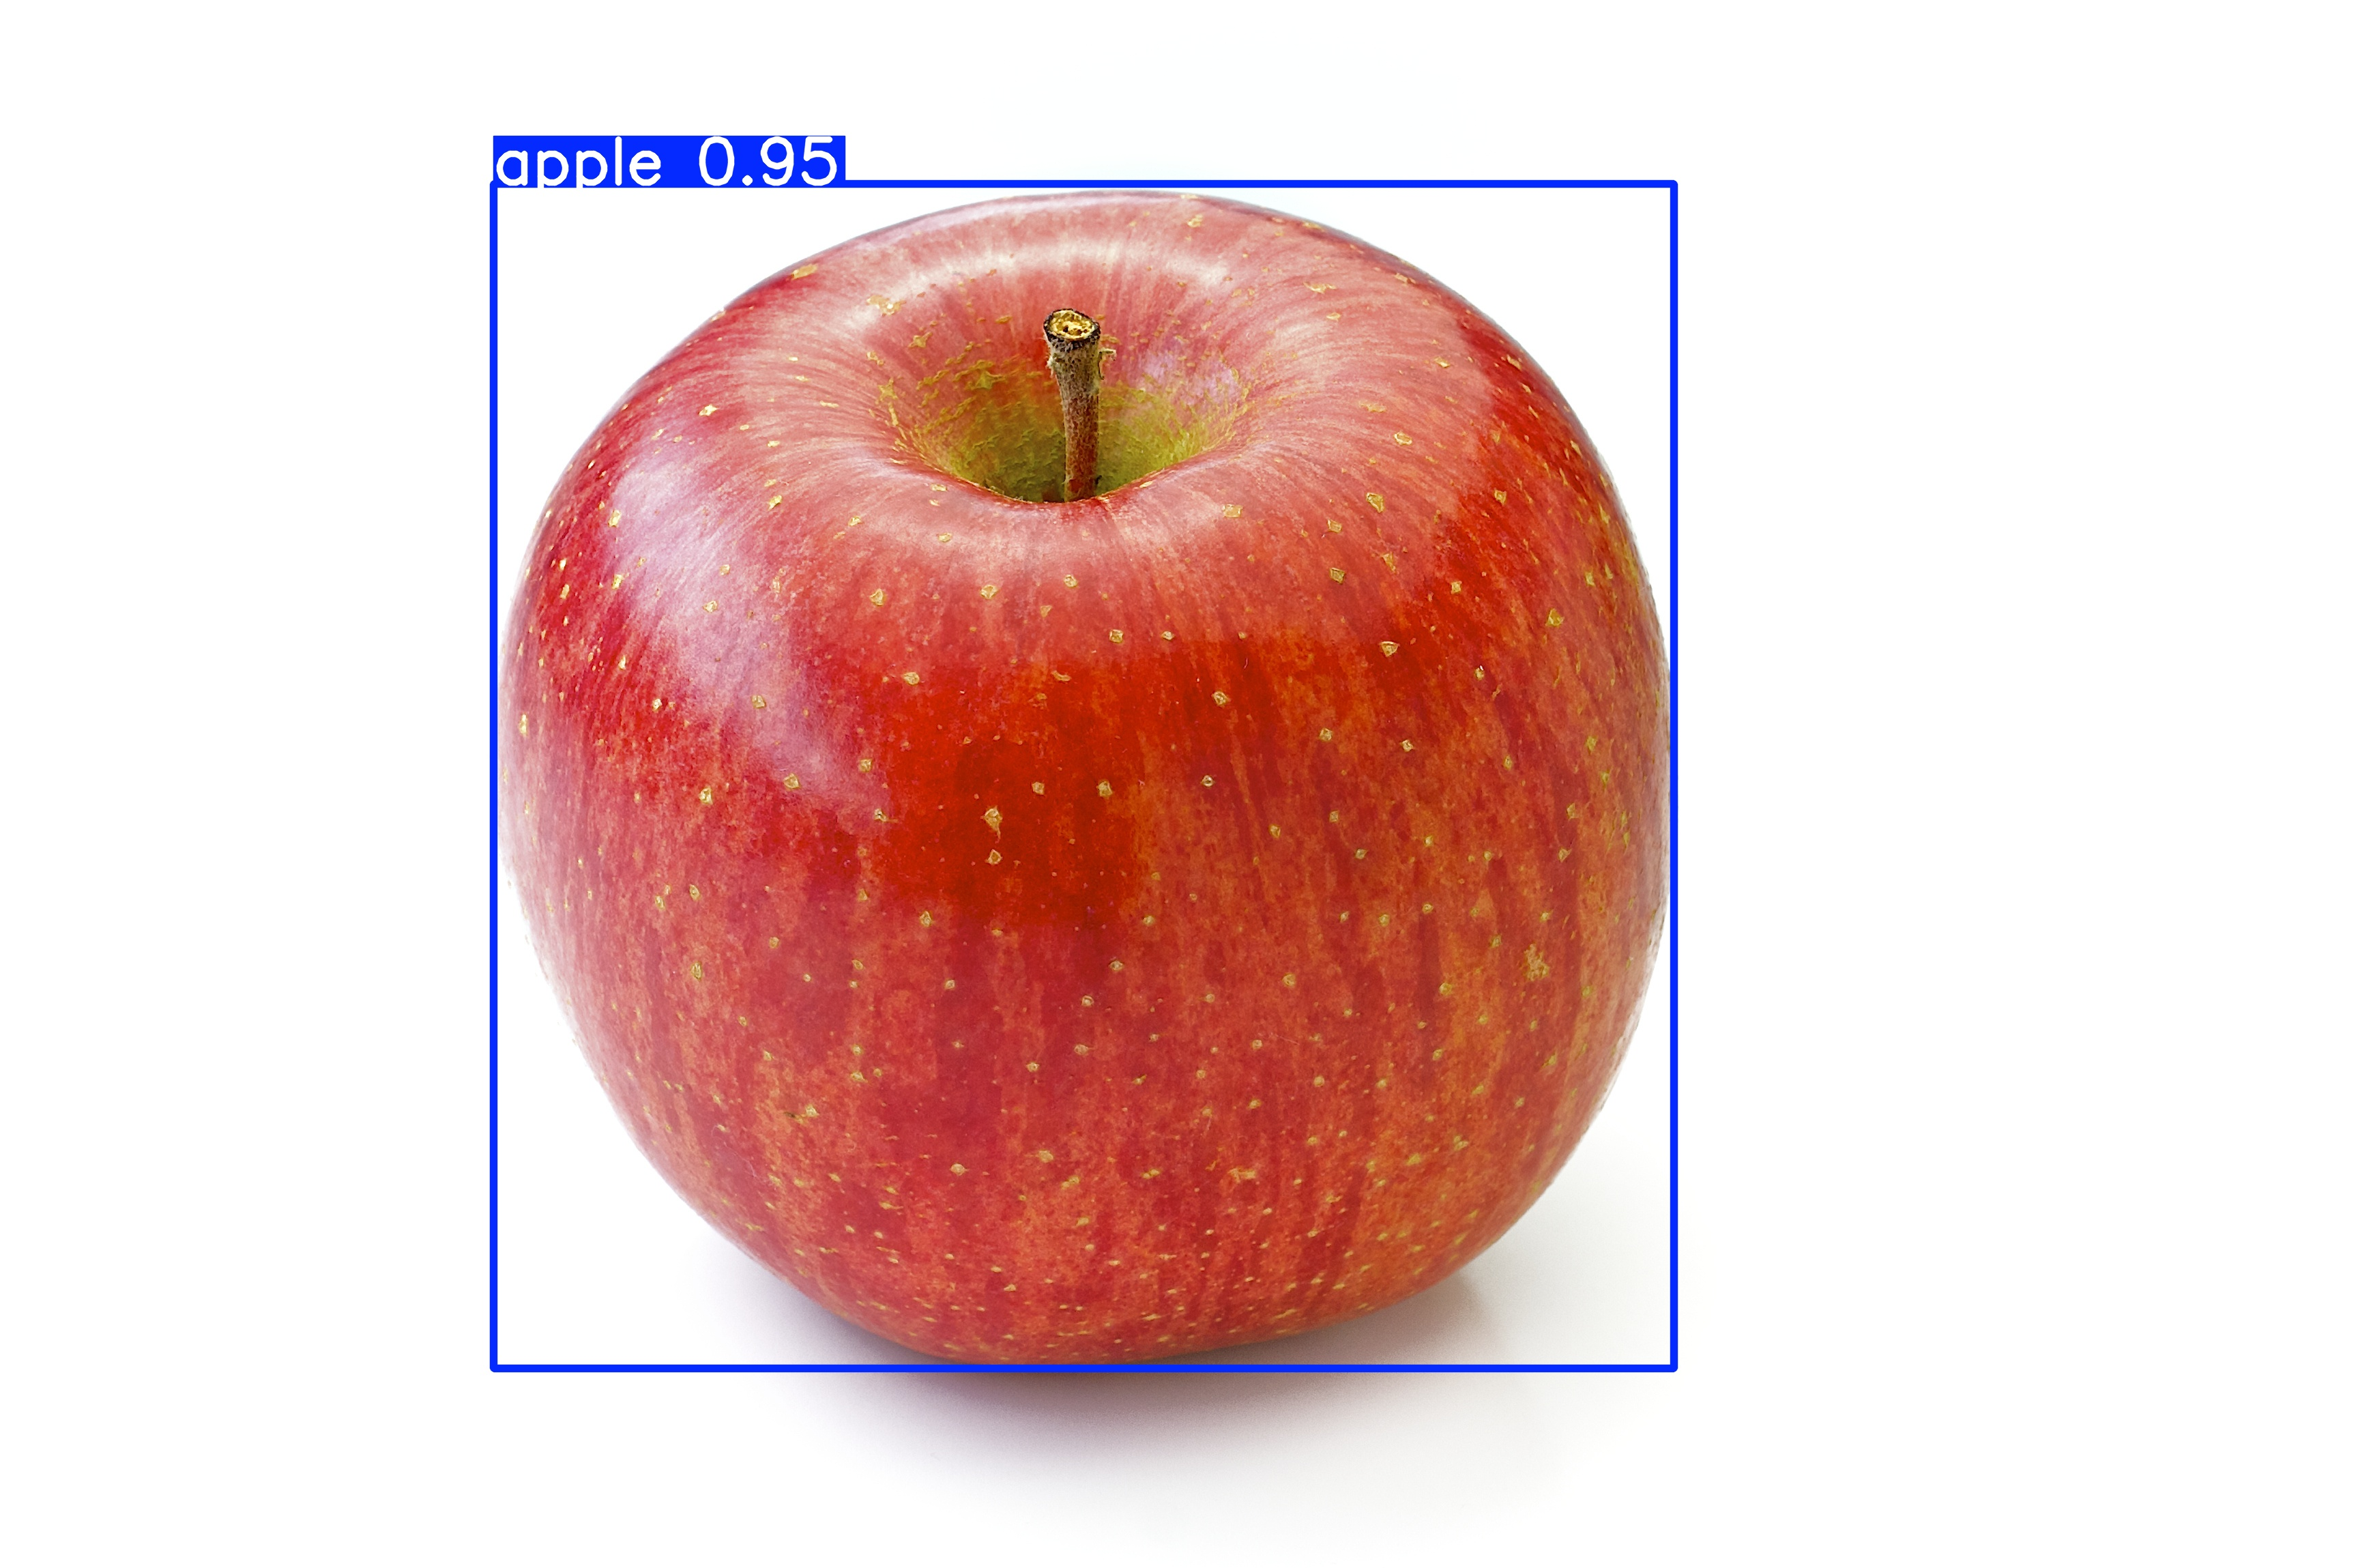

In [43]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11n.pt")  # load an official model
model = YOLO("/content/drive/MyDrive/yolov11n_project/train/weights/best.pt")  # load a custom model

# Validate the model
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map  # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps  # a list contains map50-95 of each category

Ultralytics 8.3.121 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,589,172 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2233.3±1291.3 MB/s, size: 588.7 KB)


val: Scanning /content/data/validation/labels.cache... 52 images, 0 backgrounds, 0 corrupt: 100%|██████████| 52/52 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.63it/s]


                   all         52        205      0.823      0.862      0.914       0.71
                 apple         17         22      0.717          1      0.947      0.798
                banana          6         16          1      0.867      0.991      0.793
                 lemon          7         28      0.732      0.929      0.901      0.695
                 onion          4          8      0.772          1      0.995      0.882
                potato         11         83      0.772      0.699      0.787      0.555
                tomato          8         48      0.942      0.677      0.865      0.537
Speed: 2.6ms preprocess, 16.3ms inference, 0.0ms loss, 9.7ms postprocess per image
Results saved to runs/detect/val


array([    0.79778,     0.79305,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.69539,     0.71002,       0.882,     0.71002,     0.71002,     0.71002,
           0.71002,     0.71002,     0.71002,     0.55492,     0.71002,     0.71002,     0.71002,     0.71002,     0.71002,     0.53695,     0.71002,     0.71002])

In [30]:
from ultralytics import YOLO

# Load the YOLO11 model
model = YOLO("/content/drive/MyDrive/yolov11n_project/train/weights/best.pt")

# Export the model to TFLite format
#model.export(format="tflite")   # creates 'yolo11n_float32.tflite'

# Load the exported TFLite model
tflite_model = YOLO("/content/saved_model/best_float16.tflite")

# Run inference
results = tflite_model("/content/runs/detect/predict/")

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading /content/saved_model/best_float16.tflite for TensorFlow Lite inference...
WARNING ⚠️ Metadata not found for 'model=/content/saved_model/best_float16.tflite'



ValueError: Cannot set tensor: Dimension mismatch. Got 640 but expected 320 for dimension 1 of input 0.

In [18]:
!onnx2tf -i /content/drive/MyDrive/yolov11n_project/train/weights/best.onnx --b 1

E0000 00:00:1745989982.811397   11022 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745989982.816843   11022 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered

Model optimizing started ============================================================
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/onnx2tf/onnx2tf.py", line 652, in convert
    result = subprocess.check_output(
             ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/subprocess.py", line 466, in check_output
    return run(*popenargs, stdout=PIPE, timeout=timeout, check=True,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fi

In [31]:
import os
import random
import shutil

# Paths
source_dir = "/content/data/train/images"
calib_dir = "/content/calibration_images"
num_images = 200  # Change this number depending on your calibration needs

# Create target folder
os.makedirs(calib_dir, exist_ok=True)

# Get all image filenames
image_files = [f for f in os.listdir(source_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
selected_files = random.sample(image_files, min(num_images, len(image_files)))

# Copy selected files
for file in selected_files:
    shutil.copy(os.path.join(source_dir, file), os.path.join(calib_dir, file))

print(f"✅ Copied {len(selected_files)} images to {calib_dir}")

✅ Copied 455 images to /content/calibration_images


In [32]:
import cv2
import numpy as np
import os

calib_dir = "/content/calibration_images"
calib_images = sorted(os.listdir(calib_dir))

def representative_dataset_gen():
    for img_name in calib_images:  # List of calibration images
        img_path = os.path.join(calib_dir, img_name)
        img = cv2.imread(image_path)
        img = cv2.resize(img, (320, 320))
        img = img.astype(np.float32) / 255.0  # Normalize to [0,1] if needed
        img = np.expand_dims(img, axis=0)  # Shape (1,320,320,3)
        yield [img]


In [33]:
import tensorflow as tf
# Load your TensorFlow model
model = tf.saved_model.load('/content/saved_model')  # Assuming you exported to SavedModel first

# Create TFLite Converter
converter = tf.lite.TFLiteConverter.from_saved_model('/content/saved_model')
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen

# Set fully integer quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Important: ensure input/output are int8
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert
tflite_quant_model = converter.convert()

# Save the TFLite model
with open('yolov11n_int8.tflite', 'wb') as f:
    f.write(tflite_quant_model)

In [48]:
import os
import cv2
import numpy as np
import tensorflow as tf

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/content/saved_model/best_float16.tflite")
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_shape = input_details[0]['shape']  # e.g., [1, 320, 320, 3]
print("Model expects input shape:", input_shape)

# Paths
image_dir = "/content/runs/detect/predict/"
resized_dir = "/content/resized_images"
os.makedirs(resized_dir, exist_ok=True)

# Supported formats
image_extensions = (".jpg", ".jpeg", ".png")

# Loop over images
for filename in os.listdir(image_dir):
    if filename.lower().endswith(image_extensions):
        input_path = os.path.join(image_dir, filename)
        output_path = os.path.join(resized_dir, filename)

        # Load and preprocess image
        img = cv2.imread(input_path)
        img_resized = cv2.resize(img, (input_shape[2], input_shape[1]))  # Width x Height
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        img_norm = img_rgb.astype(np.float32) / 255.0
        input_tensor = np.expand_dims(img_norm, axis=0)

        # Run inference
        interpreter.set_tensor(input_details[0]['index'], input_tensor)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details[0]['index'])

        print(f"[{filename}] Output shape:", output_data.shape)
        # Optionally: decode predictions here (e.g., NMS, thresholding)

        # Save resized image
        cv2.imwrite(output_path, img_resized)


Model expects input shape: [  1 320 320   3]
[1cf1138e-Image_86.jpg] Output shape: (1, 40, 2100)
[46f26f0c-Image_19.jpg] Output shape: (1, 40, 2100)
[11ec715b-Image_54.jpg] Output shape: (1, 40, 2100)
[07af530a-Image_93.jpg] Output shape: (1, 40, 2100)
[7d60397f-Image_9.jpg] Output shape: (1, 40, 2100)
[037af28d-Image_7.jpg] Output shape: (1, 40, 2100)
[11bae1f1-Image_59.jpg] Output shape: (1, 40, 2100)
[636c9bcb-Image_73.jpg] Output shape: (1, 40, 2100)
[90a38161-Image_20.jpg] Output shape: (1, 40, 2100)
[4dd30dc6-Image_39.jpg] Output shape: (1, 40, 2100)
[d054cc93-Image_84.jpg] Output shape: (1, 40, 2100)
[51066158-Image_61.jpg] Output shape: (1, 40, 2100)
[eee74d2f-Image_86.jpg] Output shape: (1, 40, 2100)
[46873483-Image_58.jpg] Output shape: (1, 40, 2100)
[93080c96-Image_6.jpg] Output shape: (1, 40, 2100)
[55d6e515-Image_27.jpg] Output shape: (1, 40, 2100)
[13afa9cb-Image_32.jpg] Output shape: (1, 40, 2100)
[27075cc8-Image_9.jpg] Output shape: (1, 40, 2100)
[55669f35-Image_5.jpg] 